# Project 4: Appointment Demand Forecasting

## Objective

The objective of this project is to forecast future appointment demand within NHS primary care services across Hertfordshire and West Essex using historical appointment data.

By analysing demand trends, seasonal patterns, and year-on-year changes, this project aims to estimate future appointment volumes and identify periods of increased service pressure. The findings provide insights that can support workforce planning, capacity management, and operational decision-making.

## Introduction

Healthcare providers must anticipate future demand to ensure sufficient workforce capacity and maintain timely access to care. Understanding how appointment demand changes over time is essential for effective operational planning and resource allocation.

Previous projects in this portfolio examined operational performance, patient non-attendance, and workforce utilisation within NHS primary care services. This project builds upon those findings by introducing predictive analytics through appointment demand forecasting.

Using NHS England's Appointments in General Practice dataset for Hertfordshire and West Essex, the analysis explores historical demand patterns before applying a forecasting model to estimate future appointment activity and identify periods of expected service pressure.

## Questions

This project explores the following questions:

1. How much month-to-month variation exists in appointment demand?

2. How has appointment demand changed year-on-year?

3. What is the forecasted appointment demand for the next 12 months?

4. Which periods are forecast to experience the greatest service pressure?

5. What workforce and capacity planning implications arise from the forecast?

## Dataset Overview

This analysis uses NHS England's Appointments in General Practice dataset for Hertfordshire and West Essex.

The dataset contains information relating to appointment activity within primary care services, including appointment status, appointment mode, healthcare professional type, waiting times, and appointment volumes.

For this project, the primary variables used are:

- APPOINTMENT_MONTH
- COUNT_OF_APPOINTMENTS

Appointment volumes are aggregated at monthly level to create a time series suitable for forecasting and demand analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
df = pd.read_csv("../data/Regional_CSV_HertfordshireWEssex.csv")

## Preparing the Time Series

Before forecasting future demand, appointment activity must be aggregated into a monthly time series.

This section prepares the dataset by calculating total monthly appointment volumes and converting appointment dates into a format suitable for time-series analysis.

In [3]:
monthly_demand_df = (
    df.groupby("APPOINTMENT_MONTH")["COUNT_OF_APPOINTMENTS"]
      .sum()
      .reset_index()
)

monthly_demand_df["APPOINTMENT_MONTH"] = pd.to_datetime(
    monthly_demand_df["APPOINTMENT_MONTH"],
    format="%b%Y"
)

monthly_demand_df = monthly_demand_df.sort_values(
    "APPOINTMENT_MONTH"
)

monthly_demand_df

,APPOINTMENT_MONTH,COUNT_OF_APPOINTMENTS
25,2023-10-01,792567
22,2023-11-01,726686
4,2023-12-01,601442
10,2024-01-01,755634
7,2024-02-01,714993
17,2024-03-01,694391
0,2024-04-01,699106
20,2024-05-01,693503
15,2024-06-01,649996
13,2024-07-01,713998


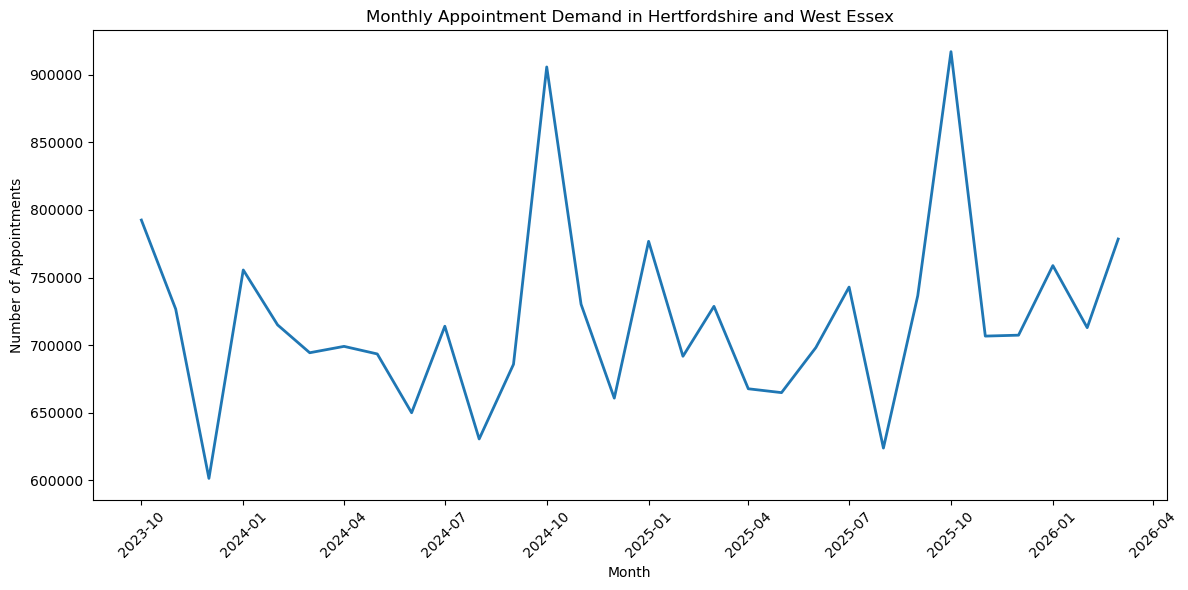

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_demand_df["APPOINTMENT_MONTH"],
    monthly_demand_df["COUNT_OF_APPOINTMENTS"],
    linewidth=2
)

plt.title("Monthly Appointment Demand in Hertfordshire and West Essex")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Question 1: How Much Month-to-Month Variation Exists in Appointment Demand?

### Why This Question Matters

Before forecasting future demand, it is important to understand how appointment activity fluctuates month to month.

Large variations can make workforce planning more challenging and may indicate periods of increased operational pressure. Understanding demand volatility also helps assess whether historical patterns are stable enough to support forecasting.

To investigate this, month-on-month percentage changes in appointment demand were calculated to identify periods of growth, decline, and overall variation.

In [5]:
monthly_demand_df["MoM_Change_Percent"] = (
    monthly_demand_df["COUNT_OF_APPOINTMENTS"]
    .pct_change() * 100
).round(2)

monthly_demand_df

,APPOINTMENT_MONTH,COUNT_OF_APPOINTMENTS,MoM_Change_Percent
25,2023-10-01,792567,NaN
22,2023-11-01,726686,-8.31
4,2023-12-01,601442,-17.23
10,2024-01-01,755634,25.64
7,2024-02-01,714993,-5.38
17,2024-03-01,694391,-2.88
0,2024-04-01,699106,0.68
20,2024-05-01,693503,-0.80
15,2024-06-01,649996,-6.27
13,2024-07-01,713998,9.85


In [6]:
monthly_demand_df.sort_values("MoM_Change_Percent", ascending=False).head()

,APPOINTMENT_MONTH,COUNT_OF_APPOINTMENTS,MoM_Change_Percent
26,2024-10-01,905822,32.07
10,2024-01-01,755634,25.64
27,2025-10-01,917131,24.51
29,2025-09-01,736588,18.07
11,2025-01-01,776818,17.55


In [7]:
monthly_demand_df.sort_values("MoM_Change_Percent").head()

,APPOINTMENT_MONTH,COUNT_OF_APPOINTMENTS,MoM_Change_Percent
24,2025-11-01,706708,-22.94
23,2024-11-01,730270,-19.38
4,2023-12-01,601442,-17.23
3,2025-08-01,623868,-16.03
2,2024-08-01,630598,-11.68


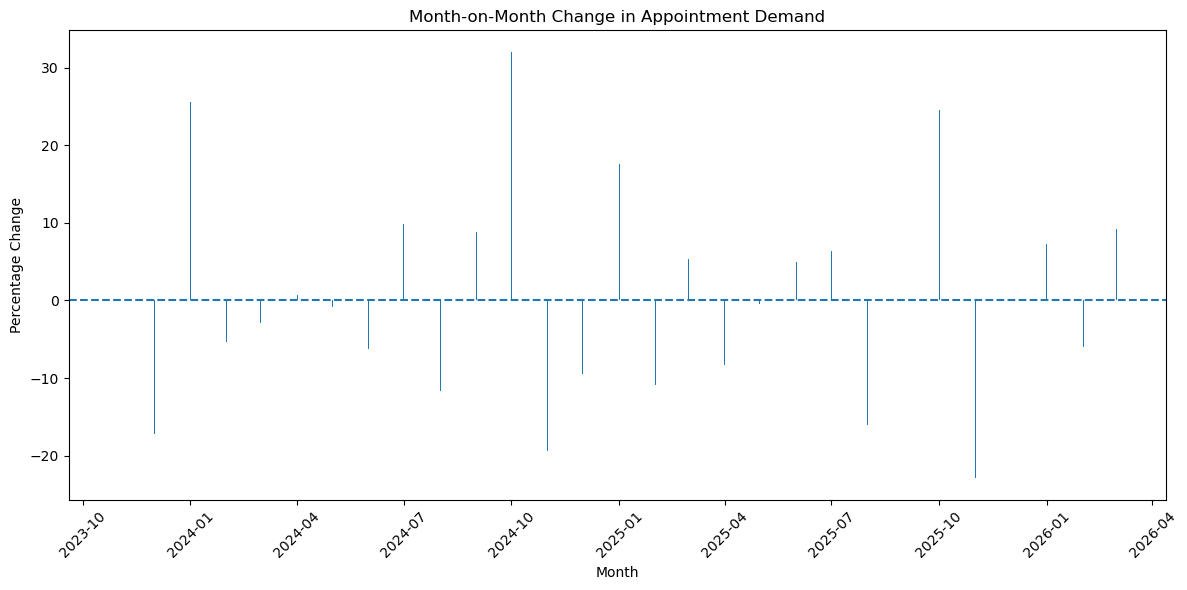

In [8]:
plt.figure(figsize=(12,6))

plt.bar(
    monthly_demand_df["APPOINTMENT_MONTH"],
    monthly_demand_df["MoM_Change_Percent"]
)

plt.axhline(y=0, linestyle="--")

plt.title("Month-on-Month Change in Appointment Demand")
plt.xlabel("Month")
plt.ylabel("Percentage Change")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Finding

Month-to-month changes in appointment demand were generally modest, indicating that overall demand remained relatively stable throughout the study period. While some months experienced larger increases or decreases, most changes were relatively small, suggesting that appointment activity follows predictable patterns rather than exhibiting extreme volatility.

The presence of recurring increases and decreases throughout the series also indicates that demand is influenced by seasonal factors, which are explored in the following section.

## Understanding Seasonal Demand Patterns

Before forecasting future demand, it is useful to understand whether appointment activity follows recurring seasonal patterns.

Certain months may consistently experience higher or lower demand, creating predictable periods of service pressure. Identifying these patterns helps improve forecasting accuracy and supports workforce planning decisions.

Average appointment demand was therefore calculated for each calendar month to identify recurring seasonal trends.

In [9]:
monthly_demand_df["Month"] = (
    monthly_demand_df["APPOINTMENT_MONTH"]
    .dt.month_name()
)

seasonality = (
    monthly_demand_df.groupby("Month")["COUNT_OF_APPOINTMENTS"]
    .mean()
    .round(0)
    .reset_index()
)

seasonality

,Month,COUNT_OF_APPOINTMENTS
0,April,683423.0
1,August,627233.0
2,December,656552.0
3,February,706573.0
4,January,763772.0
5,July,728484.0
6,June,674112.0
7,March,733878.0
8,May,679196.0
9,November,721221.0


In [10]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

seasonality["Month"] = pd.Categorical(
    seasonality["Month"],
    categories=month_order,
    ordered=True
)

seasonality = seasonality.sort_values("Month")

seasonality

,Month,COUNT_OF_APPOINTMENTS
4,January,763772.0
3,February,706573.0
7,March,733878.0
0,April,683423.0
8,May,679196.0
6,June,674112.0
5,July,728484.0
1,August,627233.0
11,September,711216.0
10,October,871840.0


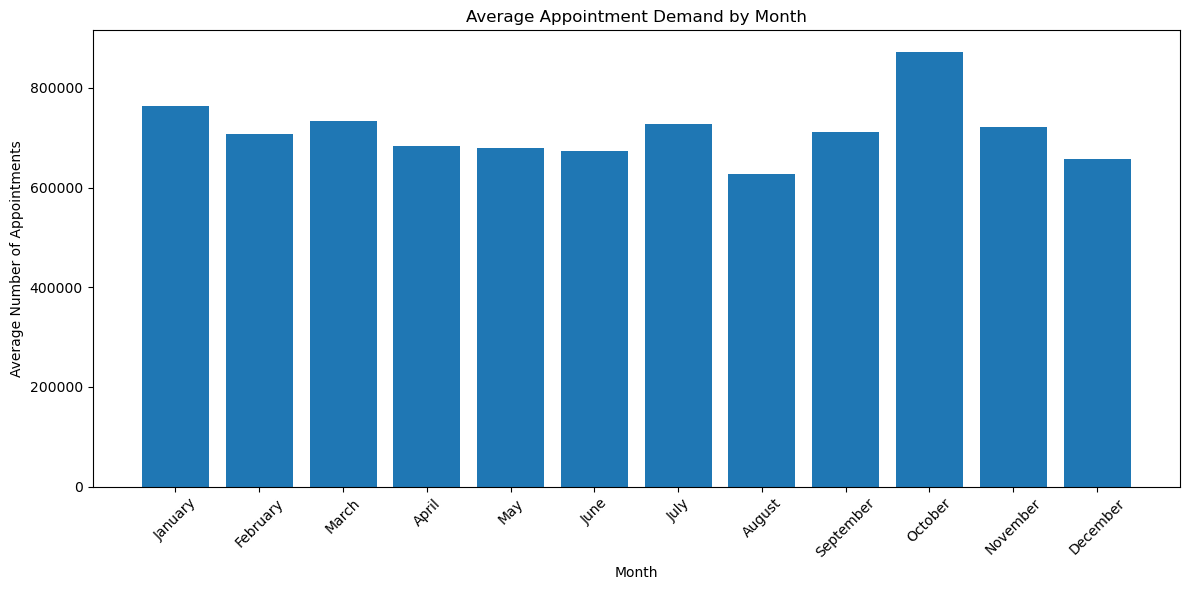

In [11]:
plt.figure(figsize=(12,6))

plt.bar(
    seasonality["Month"],
    seasonality["COUNT_OF_APPOINTMENTS"]
)

plt.title("Average Appointment Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Appointments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Finding

Average appointment demand varied across the calendar year, indicating the presence of recurring seasonal patterns. October recorded the highest average demand, while August recorded the lowest.

Demand also remained relatively elevated during January compared with most other months, whereas spring and early summer months showed more stable activity levels. These findings suggest that appointment demand follows predictable seasonal trends, which should be considered when forecasting future activity and planning workforce capacity.

## Question 2: How Has Appointment Demand Changed Year-on-Year?

### Why This Question Matters

While month-to-month analysis helps identify short-term fluctuations, year-on-year comparisons provide insight into longer-term demand trends.

Understanding whether appointment demand is growing, declining, or remaining stable helps determine whether future service capacity is likely to remain sufficient.

To investigate this, appointment volumes for 2024 and 2025 were compared and percentage changes were calculated for each month.

In [12]:
yoy_demand = monthly_demand_df.copy()

yoy_demand["Year"] = yoy_demand["APPOINTMENT_MONTH"].dt.year
yoy_demand["Month"] = yoy_demand["APPOINTMENT_MONTH"].dt.month_name()

yoy_pivot = (
    yoy_demand.pivot(
        index="Month",
        columns="Year",
        values="COUNT_OF_APPOINTMENTS"
    )
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

yoy_pivot = yoy_pivot.reindex(month_order)

yoy_pivot["YoY_Change_Percent"] = (
    (yoy_pivot[2025] - yoy_pivot[2024])
    / yoy_pivot[2024]
    * 100
).round(2)

yoy_pivot

Year,2023,2024,2025,2026,YoY_Change_Percent
Month,,,,,
January,NaN,755634.0,776818.0,758864.0,2.80
February,NaN,714993.0,691785.0,712942.0,-3.25
March,NaN,694391.0,728723.0,778521.0,4.94
April,NaN,699106.0,667740.0,NaN,-4.49
May,NaN,693503.0,664888.0,NaN,-4.13
June,NaN,649996.0,698227.0,NaN,7.42
July,NaN,713998.0,742971.0,NaN,4.06
August,NaN,630598.0,623868.0,NaN,-1.07
September,NaN,685845.0,736588.0,NaN,7.40


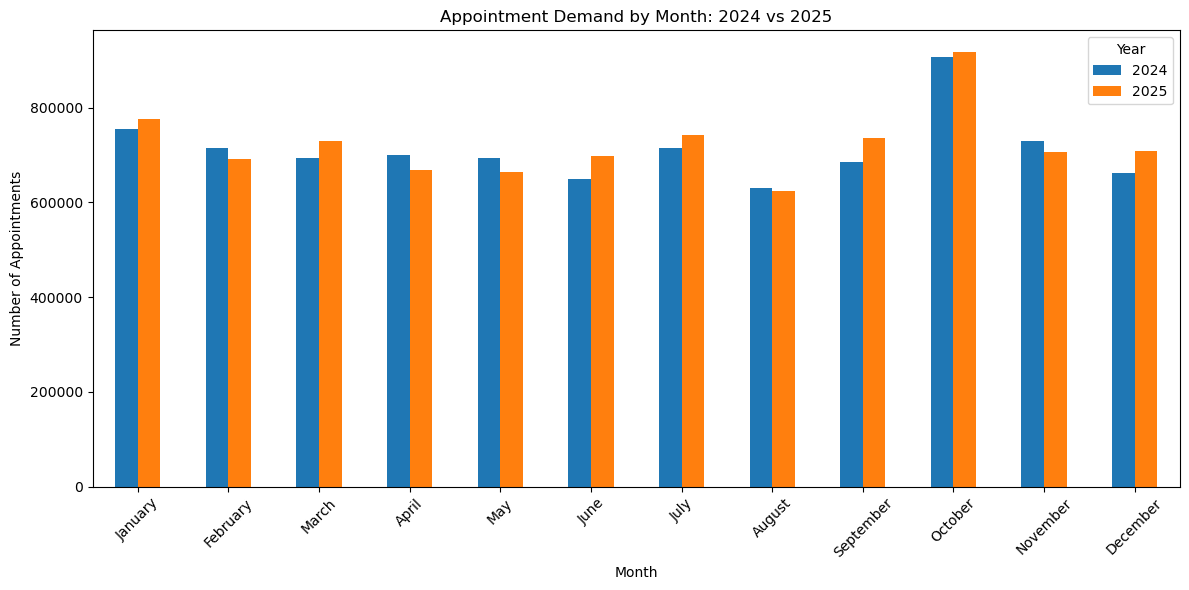

In [13]:
yoy_pivot[[2024, 2025]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Appointment Demand by Month: 2024 vs 2025")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Finding

Year-on-year appointment demand remained relatively stable between 2024 and 2025. Most months experienced changes of less than 8%, indicating that overall demand patterns were broadly consistent across both years.

The largest increases were observed in June (+7.42%), September (+7.40%), and December (+7.05%), while the largest decreases occurred in April (-4.49%), May (-4.13%), and February (-3.25%).

Despite some monthly variation, demand levels in 2025 closely mirrored those observed in 2024. This stability suggests that historical demand patterns provide a reasonable basis for forecasting future appointment volumes.

## Question 3: What Is the Forecasted Appointment Demand for the Next 12 Months?

### Why This Question Matters

Forecasting future demand enables healthcare organisations to move beyond reporting historical activity and begin planning for future service requirements.

Accurate demand forecasts can support workforce planning, resource allocation, and operational decision-making by identifying expected levels of future activity.

A forecasting model was therefore developed using historical appointment volumes to estimate appointment demand over the next 12 months.

In [14]:
#ExponentialSmoothing for prediction is used here

demand_series = monthly_demand_df.set_index(
    "APPOINTMENT_MONTH"
)["COUNT_OF_APPOINTMENTS"]

demand_series = demand_series.asfreq("MS")
demand_series

APPOINTMENT_MONTH
2023-10-01    792567
2023-11-01    726686
2023-12-01    601442
2024-01-01    755634
2024-02-01    714993
2024-03-01    694391
2024-04-01    699106
2024-05-01    693503
2024-06-01    649996
2024-07-01    713998
2024-08-01    630598
2024-09-01    685845
2024-10-01    905822
2024-11-01    730270
2024-12-01    660818
2025-01-01    776818
2025-02-01    691785
2025-03-01    728723
2025-04-01    667740
2025-05-01    664888
2025-06-01    698227
2025-07-01    742971
2025-08-01    623868
2025-09-01    736588
2025-10-01    917131
2025-11-01    706708
2025-12-01    707395
2026-01-01    758864
2026-02-01    712942
2026-03-01    778521
Freq: MS, Name: COUNT_OF_APPOINTMENTS, dtype: int64

In [15]:
model = ExponentialSmoothing(
    demand_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

forecast = model.forecast(12).round(0).astype(int)

forecast

2026-04-01    726320
2026-05-01    716716
2026-06-01    671469
2026-07-01    732977
2026-08-01    650518
2026-09-01    706179
2026-10-01    926866
2026-11-01    754693
2026-12-01    685292
2027-01-01    798936
2027-02-01    713861
2027-03-01    749824
Freq: MS, dtype: int64

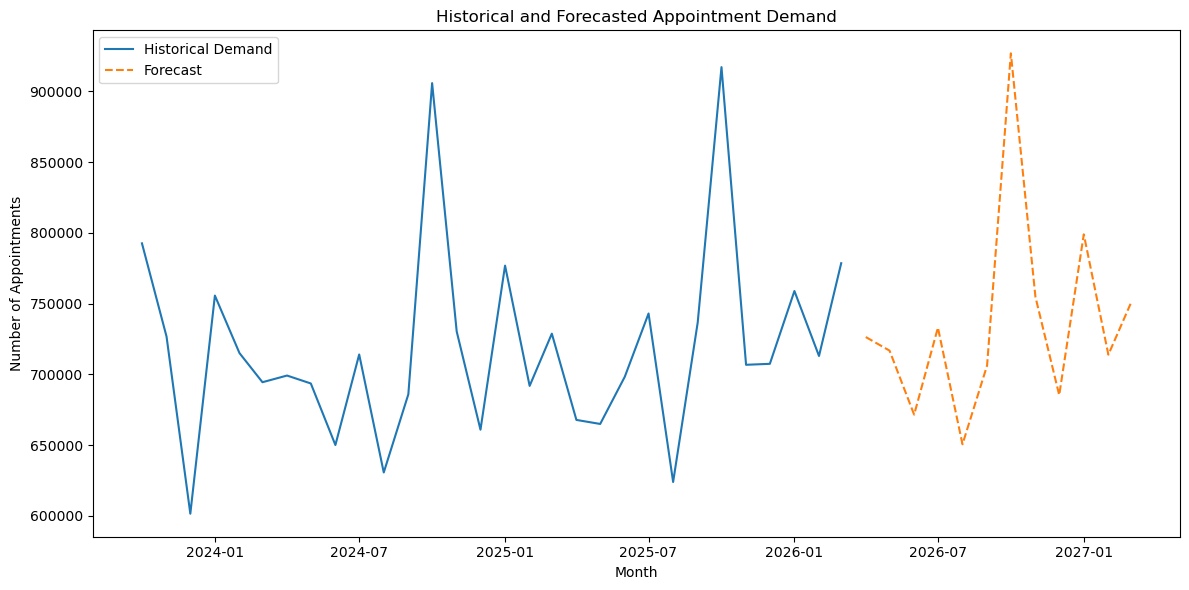

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    demand_series.index,
    demand_series.values,
    label="Historical Demand"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast",
    linestyle="--"
)

plt.title("Historical and Forecasted Appointment Demand")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")

plt.legend()
plt.tight_layout()

plt.show()

### Finding

The forecasting model predicts that appointment demand will remain relatively stable throughout the next 12 months, with expected monthly activity ranging from approximately 650,000 to 927,000 appointments.

Seasonal patterns observed in the historical data are projected to continue, with October 2026 forecast to remain the busiest month and August 2026 remaining among the lowest-demand periods.

The forecast does not indicate substantial long-term growth or decline in demand. Instead, future activity is expected to follow patterns similar to those observed historically, suggesting that healthcare providers should continue planning for recurring seasonal fluctuations rather than major structural changes in demand.

## Question 4: Which Periods Are Forecast to Experience the Greatest Service Pressure?

### Why This Question Matters

Forecasts are most useful when they help decision-makers prepare for future demand.

Identifying periods of expected service pressure allows healthcare providers to allocate resources effectively, manage workforce capacity, and maintain patient access during high-demand periods.

Forecasted appointment volumes were therefore ranked to identify the months expected to experience the highest and lowest levels of demand.

In [17]:
forecast_df = forecast.reset_index()

forecast_df.columns = [
    "Forecast_Month",
    "Forecast_Appointments"
]

forecast_df = forecast_df.sort_values(
    "Forecast_Appointments",
    ascending=False
)

forecast_df

,Forecast_Month,Forecast_Appointments
6,2026-10-01,926866
9,2027-01-01,798936
7,2026-11-01,754693
11,2027-03-01,749824
3,2026-07-01,732977
0,2026-04-01,726320
1,2026-05-01,716716
10,2027-02-01,713861
5,2026-09-01,706179
8,2026-12-01,685292


### Finding

The forecast suggests that October 2026 will experience the greatest service pressure, with an expected demand of approximately 926,866 appointments. Elevated demand is also forecast during November 2026, January 2027, and March 2027, indicating that operational pressure may remain high across late autumn and winter.

In contrast, August 2026 is forecast to experience the lowest demand, followed by June and December 2026. These periods may provide opportunities for workforce training, annual leave scheduling, and service improvement activities.

The forecast therefore suggests that capacity planning efforts should focus on preparing for recurring peaks in autumn and winter demand while leveraging lower-demand periods to support operational resilience.

Forecasts should be interpreted as model-based estimates rather than precise predictions, as future demand may be influenced by factors not captured within the historical data.

## Question 5: What Workforce and Capacity Planning Implications Arise from the Forecast?

### Why This Question Matters

The ultimate purpose of forecasting is to support decision-making.

Understanding future demand patterns helps healthcare organisations prepare for periods of increased service pressure while making effective use of lower-demand periods.

This final section considers how the forecast findings may inform workforce planning, appointment capacity management, and operational decision-making within primary care services.

### Finding

The forecast suggests that appointment demand will remain broadly stable over the next 12 months, with recurring seasonal peaks expected during autumn and winter. October 2026 is forecast to experience the highest demand, while August 2026 is forecast to have the lowest demand.

These findings indicate that healthcare providers should focus on managing predictable seasonal fluctuations rather than preparing for substantial growth in overall demand. Workforce and appointment capacity should be prioritised during high-demand periods, particularly October through January, while lower-demand months may provide opportunities for staff training, annual leave planning, and service improvement activities.

Overall, the forecast does not suggest a need for major expansion of service capacity. Instead, organisations should focus on maintaining sufficient flexibility to respond effectively to recurring seasonal demand patterns.

## Key Findings

- Appointment demand remained relatively stable overall, although notable month-to-month fluctuations were observed throughout the study period.

- Seasonal demand patterns were evident, with October consistently recording the highest levels of appointment activity and August generally experiencing the lowest demand.

- Year-on-year demand remained broadly stable between 2024 and 2025, with most monthly changes remaining within a relatively narrow range.

- The forecasting model predicts that appointment demand will remain stable over the next 12 months, with expected monthly activity ranging from approximately 650,000 to 927,000 appointments.

- October 2026 is forecast to experience the highest demand, while August 2026 is forecast to experience the lowest demand.

- Recurring autumn and winter peaks suggest that workforce and capacity planning efforts should focus on these periods of increased service pressure.

- October repeatedly emerged as a high-demand month across historical, seasonal, and forecast analyses. While the dataset does not explain the underlying drivers of this pattern, the consistency of this finding suggests that October demand warrants further investigation in future analyses.

## Conclusion

This project explored historical appointment demand patterns within NHS primary care services across Hertfordshire and West Essex and introduced predictive analytics through appointment demand forecasting.

The analysis found that appointment demand remained broadly stable over time, despite periods of month-to-month variation. Seasonal patterns were evident throughout the dataset, with October consistently recording elevated levels of activity and August generally experiencing lower demand. Year-on-year comparisons further demonstrated that overall demand patterns remained relatively stable between 2024 and 2025.

Using historical appointment volumes, a forecasting model was developed to estimate demand over the following 12 months. The forecast suggests that future activity is likely to remain within historical ranges, with no evidence of substantial long-term growth or decline. However, recurring seasonal peaks are expected to continue, particularly during autumn and winter periods.

These findings highlight the value of forecasting as a tool for workforce planning and capacity management. By identifying periods of anticipated service pressure, healthcare providers can make more informed operational decisions and allocate resources more effectively.

A notable finding throughout the project was the repeated emergence of October as a peak-demand month. While the dataset does not provide sufficient information to determine the causes of this pattern, its consistency across multiple analyses suggests that it represents a meaningful operational phenomenon worthy of further investigation.

Overall, this project demonstrates how historical healthcare activity data can be transformed into actionable forecasts that support evidence-based decision-making and healthcare service planning.